In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import time

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import calendar
import matplotlib.patches as mpatches
import seaborn as sns

from pylab import rcParams
rcParams['axes.labelweight'] = 'bold'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'bold'


In [2]:
def decode_time(filepath):
    ds = xr.open_dataset(filepath, decode_times=False)
    units, reference_date = ds.time.attrs['units'].split('since')
    ds['time'] = pd.date_range(start=reference_date, periods=ds.sizes['time'], freq='MS')
    return ds


In [ ]:
fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst = decode_time(fp)

ocean_mask = ~sst.isel(time = 1).sst.isnull()

In [41]:
fp = '/data/jmex/ERA5/monthly/era5_t2m.nc'
t2m = decode_time(fp).where(ocean_mask)

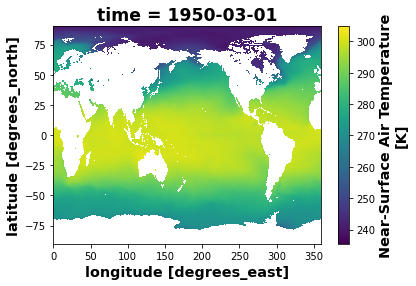

In [43]:
t2m.t2m.isel(time = 1).plot()

In [38]:
clim = t2m.sel(time = slice('1990', '2020')).t2m.groupby('time.month').mean()
t2m['anom'] = t2m.glb_mean.groupby('time.month') -clim

In [39]:
t2m['anom'] = t2m.glb_mean.groupby('time.month') -clim

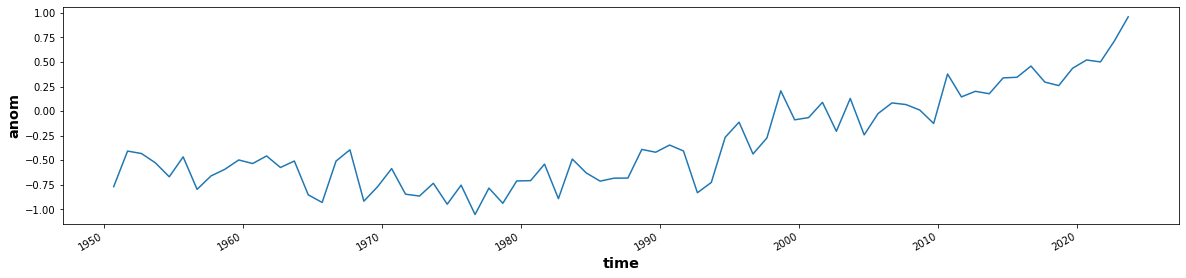

In [40]:
t2m.anom.where(t2m.time.dt.month == 9, drop = True).plot(size = 4, aspect = 5)

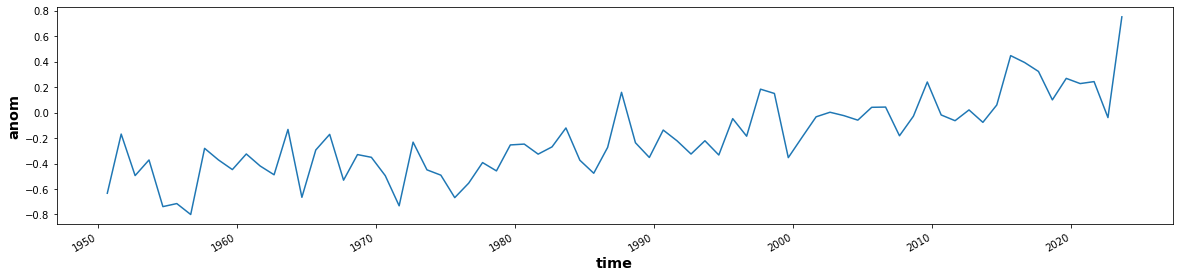

In [35]:
t2m.anom.where(t2m.time.dt.month == 9, drop = True).plot(size = 4, aspect = 5)

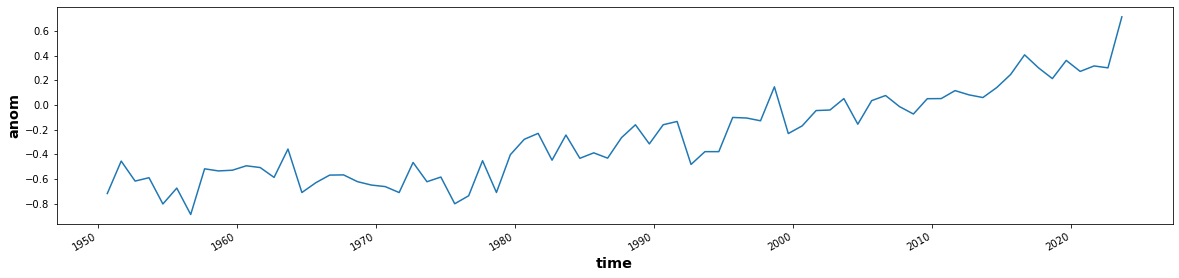

In [25]:
t2m.anom.where(t2m.time.dt.month == 9, drop = True).plot(size = 4, aspect = 5)

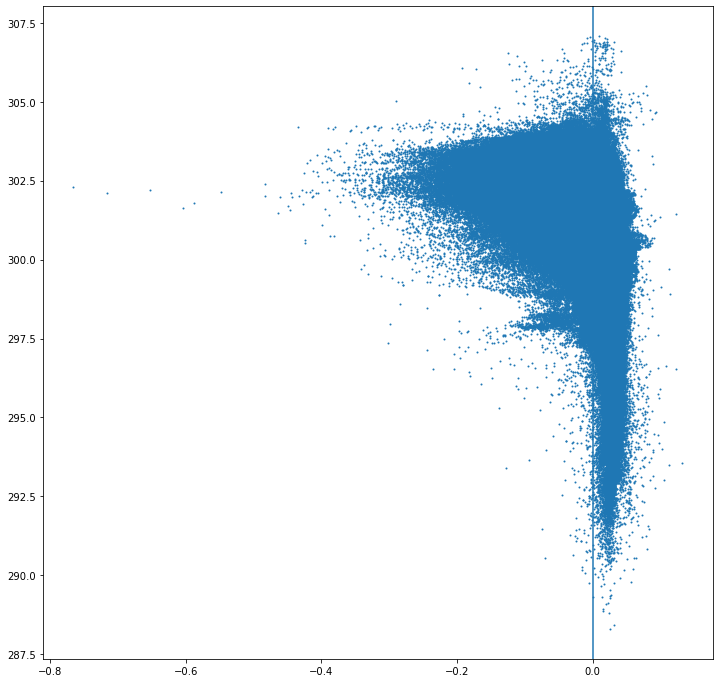

In [152]:
s = sst.sel(time = '2023').sst
w = w500.sel(time = '2023').w

plt.figure(figsize = (12,12))
plt.scatter(w.data, s.data, s = 1)

s = sst.sel(time = '2015').sst
w = w500.sel(time = '2015').w
#plt.scatter(w.data, s.data, s = 1, alpha = 0.3)

plt.axvline(x = 0)


In [183]:
#import tp: 
t0 = time.time()

#Coarsen
coarsen_factor = 10

fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst = decode_time(fp).sel(lat = slice(15, -15)).sel(time = slice('2023-01', '2023-06'))
sst = sst.coarsen(lat=coarsen_factor, lon=coarsen_factor, boundary='trim').mean()


fp = '/data/jmex/ERA5/monthly/era5_w500_0-360E_-35-35N.nc'
w500 = decode_time(fp).sel(lat = slice(15, -15)).sel(time = slice('2023-01', '2023-06'))
w500 = w500.coarsen(lat=coarsen_factor, lon=coarsen_factor, boundary='trim').mean()

print(time.time()-t0)
df = pd.DataFrame({
    'sst': sst['sst'].values.flatten(),
    'w500': w500['w'].values.flatten()
}).dropna()


0.4688863754272461


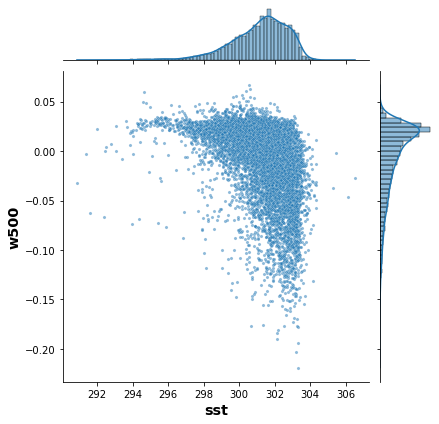

In [184]:




# Now you can use the combined dataframe for visualization
g = sns.JointGrid(data=df, x="sst", y="w500")
g.plot_joint(sns.scatterplot, s=10, alpha=.5)
g.plot_marginals(sns.histplot, kde=True)



In [185]:
#import tp: 
t0 = time.time()

#Coarsen
coarsen_factor = 10

fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst = decode_time(fp).sel(lat = slice(15, -15)).sel(time = slice('2015-01', '2015-06'))
sst = sst.coarsen(lat=coarsen_factor, lon=coarsen_factor, boundary='trim').mean()


fp = '/data/jmex/ERA5/monthly/era5_w500_0-360E_-35-35N.nc'
w500 = decode_time(fp).sel(lat = slice(15, -15)).sel(time = slice('2015-01', '2015-06'))
w500 = w500.coarsen(lat=coarsen_factor, lon=coarsen_factor, boundary='trim').mean()

print(time.time()-t0)
df2 = pd.DataFrame({
    'sst': sst['sst'].values.flatten(),
    'w500': w500['w'].values.flatten()
}).dropna()


# Assuming you have two dataframes df23 and df15 with variables sst and precipitation

# Add a new column 'year' to each dataframe
df['year'] = 2023
df2['year'] = 2015

# Join the two dataframes into one
combined_df = pd.concat([df, df2], ignore_index=True)



0.43997788429260254


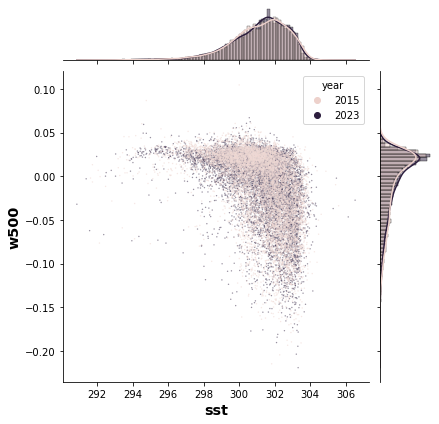

In [186]:


# Now you can use the combined dataframe for visualization
g = sns.JointGrid(data=combined_df, x="sst", y="w500", hue = 'year')
g.plot_joint(sns.scatterplot, s=2, alpha=.5)
g.plot_marginals(sns.histplot, kde=True)



In [112]:

sst_profile = sst.sel(lon = slice(120, 300)).mean(['lat'])
w500_profile = w500.sel(lon = slice(120, 300)).mean(['lat'])

In [115]:
w500_profile = w500.sel(lon = slice(120, 300)).mean(['lat'])

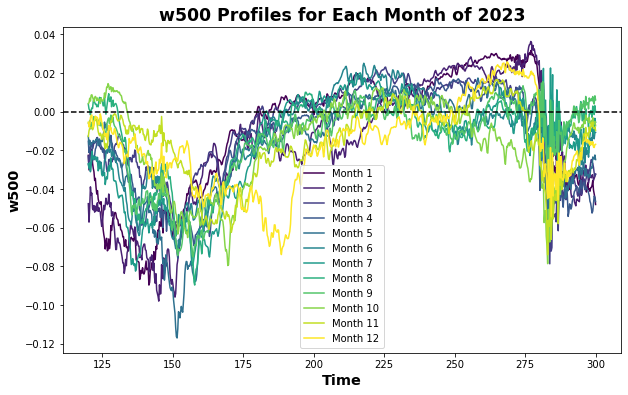

In [122]:
# Assuming `w500_profile` is your xarray DataArray or Dataset with 'time' and 'w500' variables

# Define the months
months = range(1, 13)

# Create a colormap with 12 distinct colors
cmap = plt.get_cmap('viridis')  # 'tab12' has 12 distinct colors
colors = [cmap(i) for i in np.linspace(0, 1, len(months))]

plt.figure(figsize=(10, 6))

# Plot the w500 profiles for each month with corresponding colors
for m, color in zip(months, colors):
    w500_profile.sel(time='2023-{:02d}'.format(m)).w.plot(label='Month {}'.format(m), color=color)

    

plt.legend()
plt.title('w500 Profiles for Each Month of 2023')
plt.xlabel('Time')
plt.ylabel('w500')
plt.axhline(y = 0,c = 'k', linestyle = '--')
plt.show()


<Figure size 720x432 with 0 Axes>

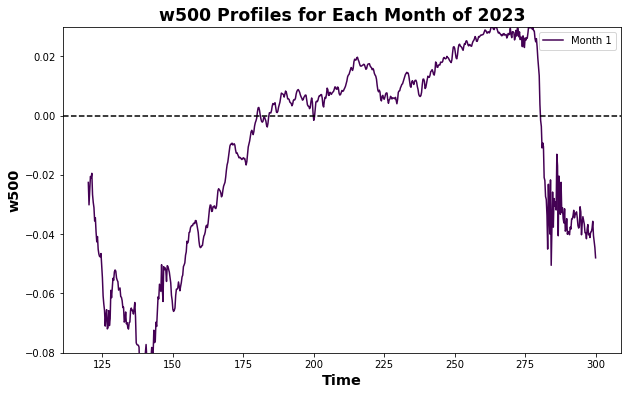

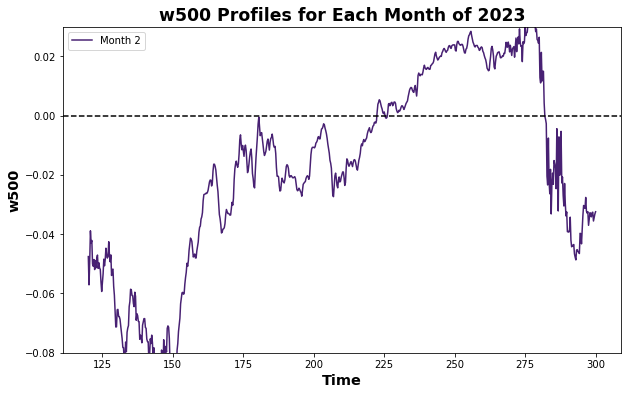

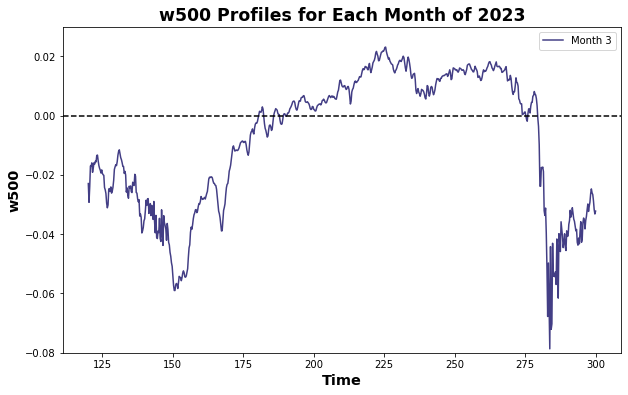

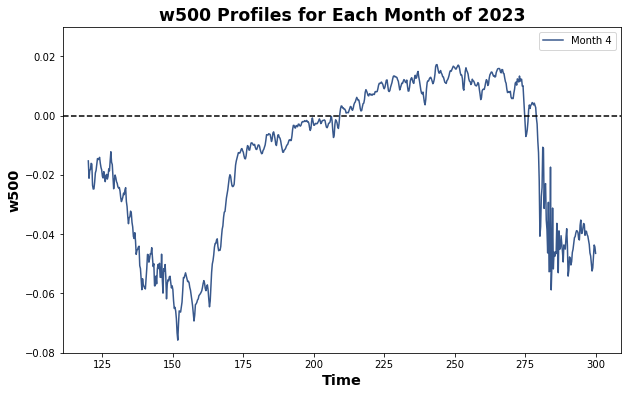

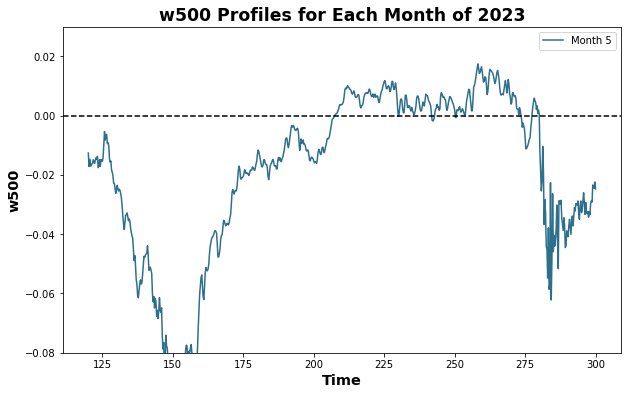

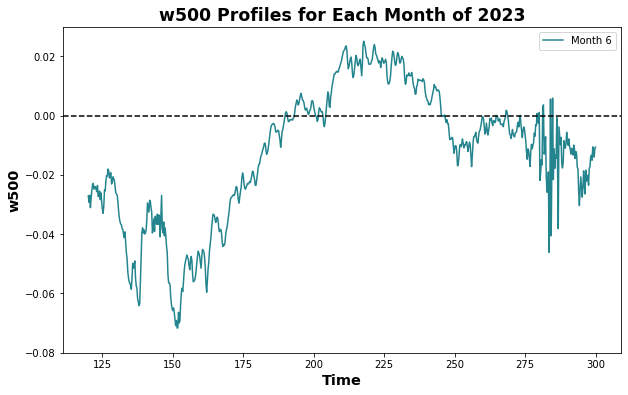

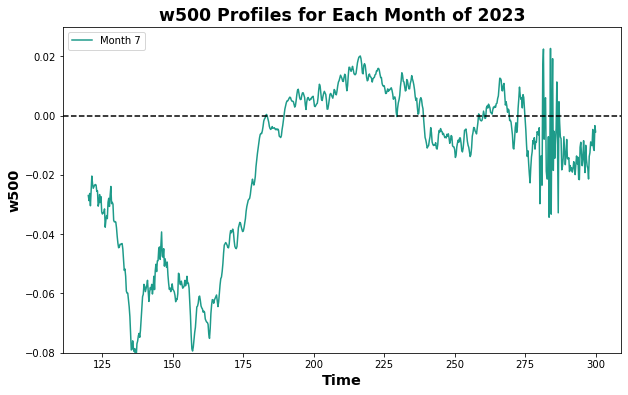

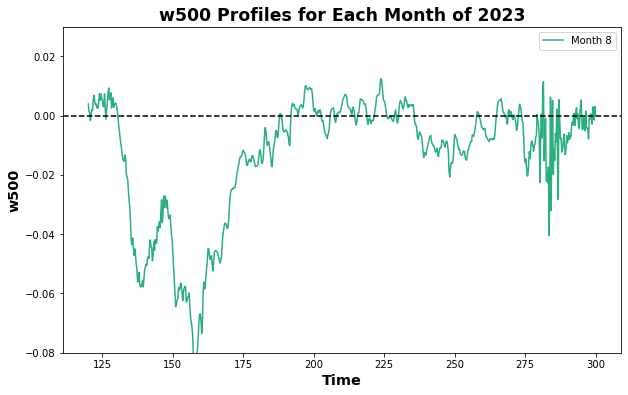

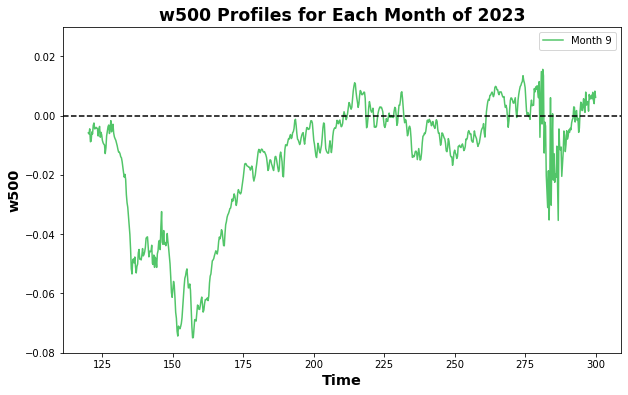

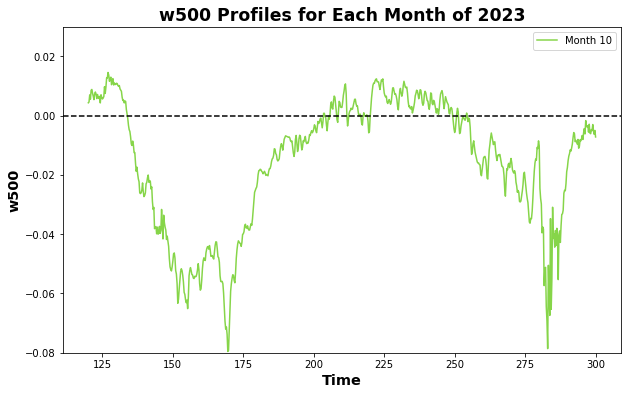

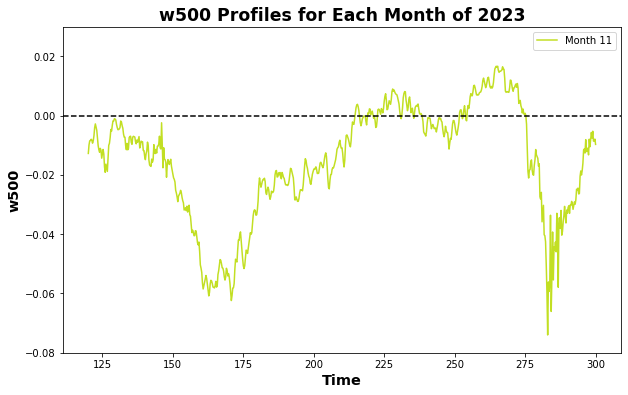

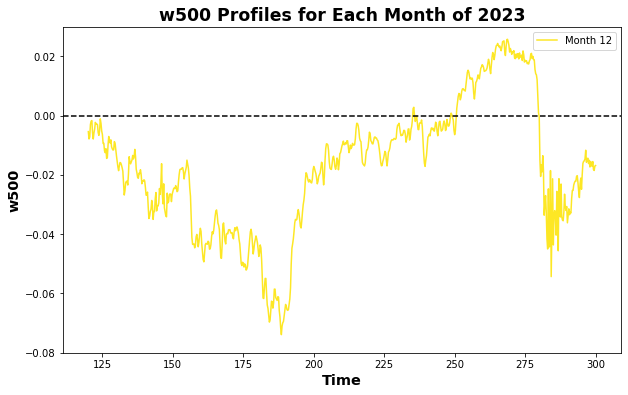

In [127]:
# Assuming `w500_profile` is your xarray DataArray or Dataset with 'time' and 'w500' variables

# Define the months
months = range(1, 13)

# Create a colormap with 12 distinct colors
cmap = plt.get_cmap('viridis')  # 'tab12' has 12 distinct colors
colors = [cmap(i) for i in np.linspace(0, 1, len(months))]

plt.figure(figsize=(10, 6))

# Plot the w500 profiles for each month with corresponding colors
for m, color in zip(months, colors):
    plt.figure(figsize=(10, 6))

    w500_profile.sel(time='2023-{:02d}'.format(m)).w.plot(label='Month {}'.format(m), color=color)
    

    

    plt.legend()
    plt.title('w500 Profiles for Each Month of 2023')
    plt.xlabel('Time')
    plt.ylabel('w500')
    plt.ylim(-0.08, 0.03)

    plt.axhline(y = 0,c = 'k', linestyle = '--')

    plt.show()


<Figure size 720x432 with 0 Axes>

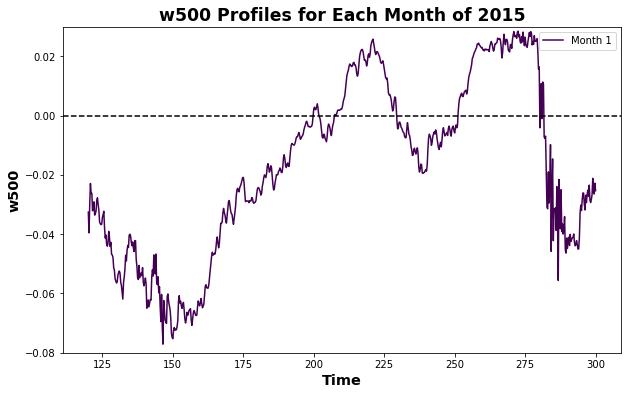

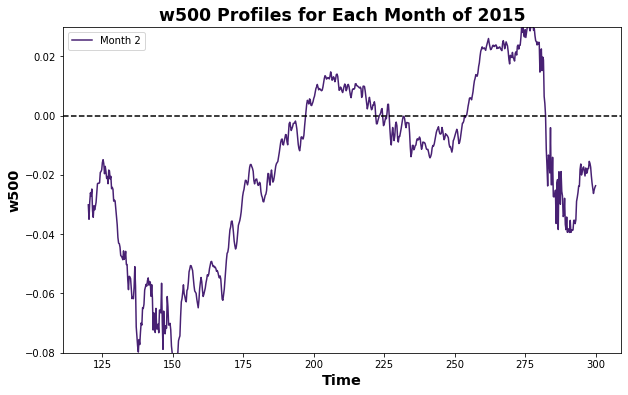

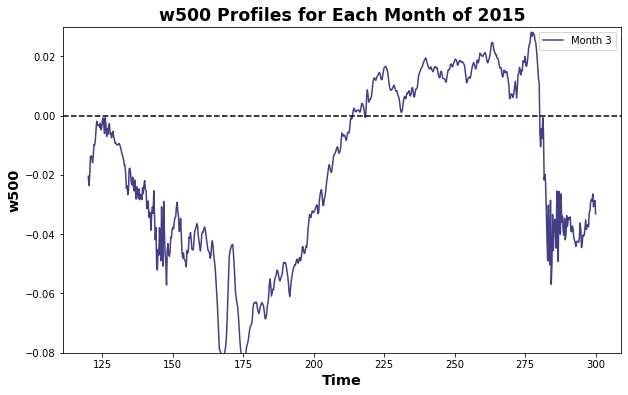

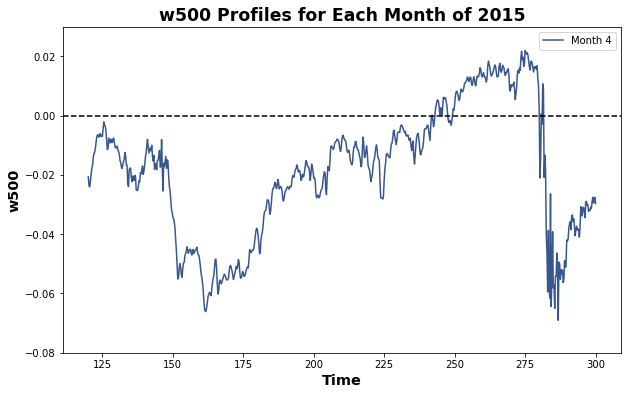

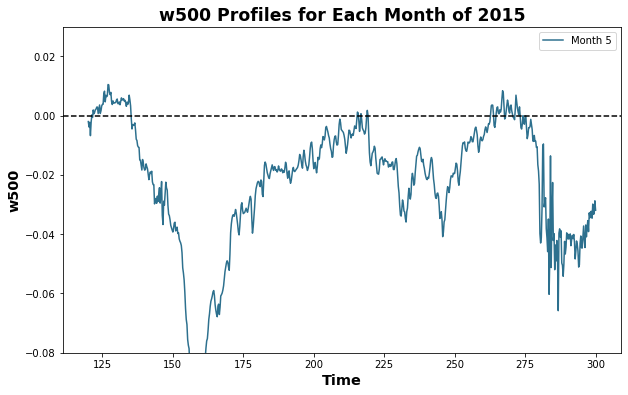

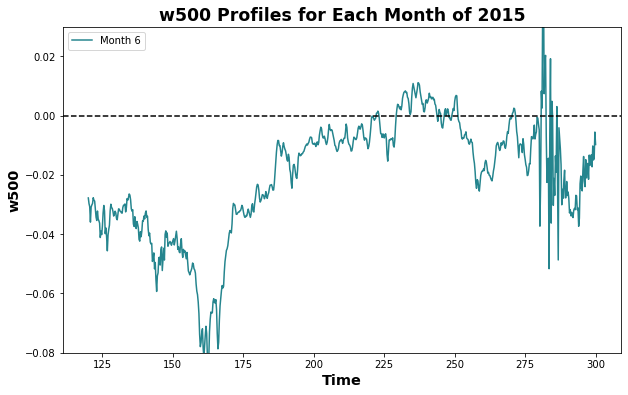

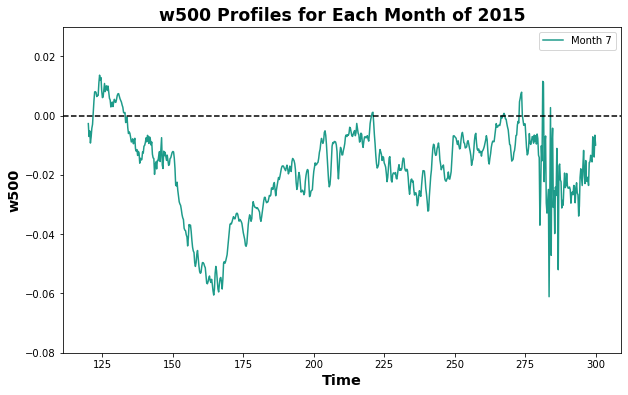

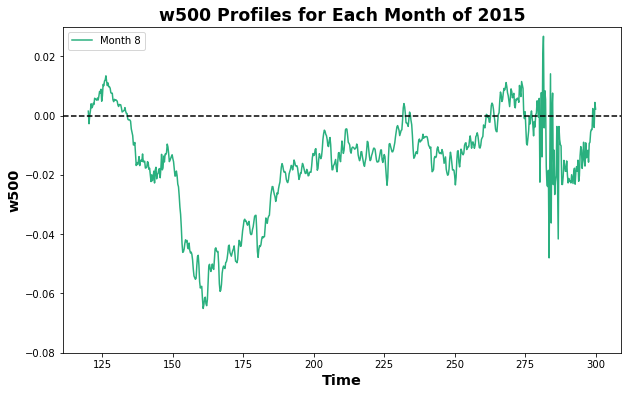

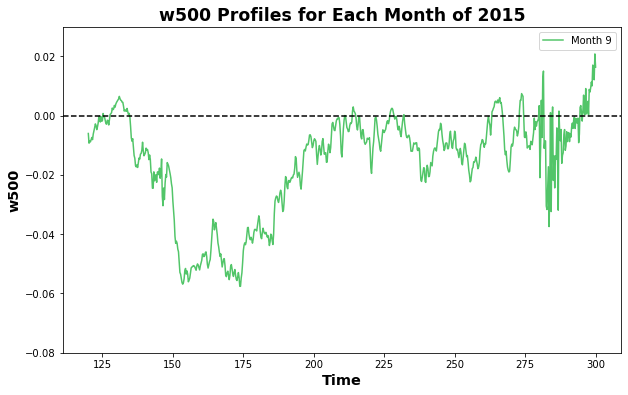

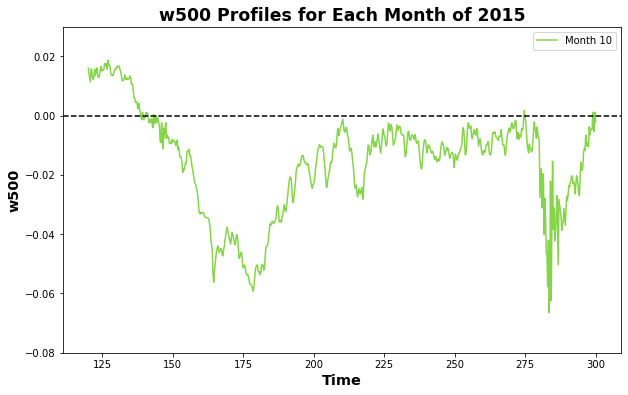

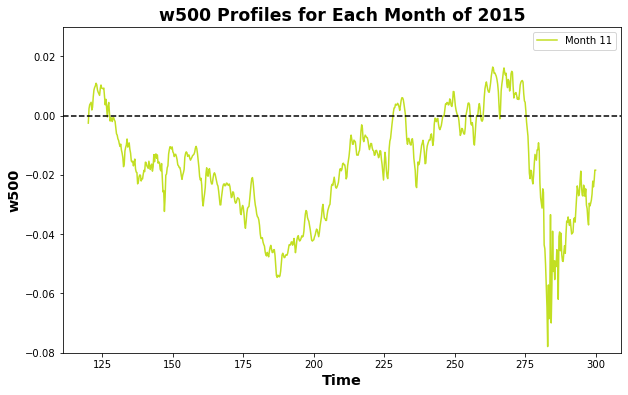

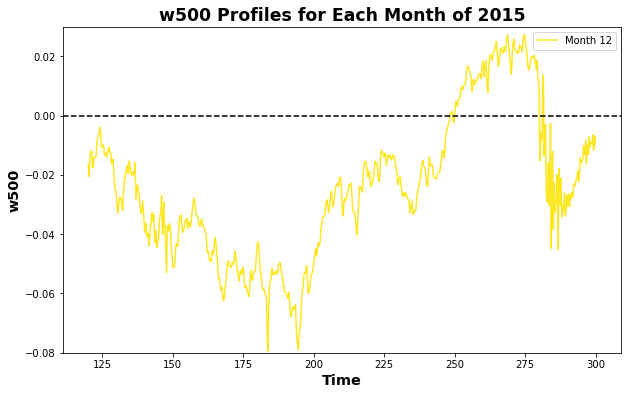

In [126]:
# Assuming `w500_profile` is your xarray DataArray or Dataset with 'time' and 'w500' variables

# Define the months
months = range(1, 13)

# Create a colormap with 12 distinct colors
cmap = plt.get_cmap('viridis')  # 'tab12' has 12 distinct colors
colors = [cmap(i) for i in np.linspace(0, 1, len(months))]

plt.figure(figsize=(10, 6))

# Plot the w500 profiles for each month with corresponding colors
for m, color in zip(months, colors):
    plt.figure(figsize=(10, 6))

    w500_profile.sel(time='2015-{:02d}'.format(m)).w.plot(label='Month {}'.format(m), color=color)
    

    

    plt.legend()
    plt.title('w500 Profiles for Each Month of 2015')
    plt.xlabel('Time')
    plt.ylabel('w500')
    plt.ylim(-0.08, 0.03)
    plt.axhline(y = 0,c = 'k', linestyle = '--')

    plt.show()


In [117]:
w500_profile

<xarray.Dataset>
Dimensions:  (time: 890, lon: 721)
Coordinates:
  * time     (time) datetime64[ns] 1950-01-01 1950-02-01 ... 2024-02-01
  * lon      (lon) float32 120.0 120.2 120.5 120.8 ... 299.2 299.5 299.8 300.0
Data variables:
    w        (time, lon) float32 -0.08745 -0.09587 ... -0.01582 -0.01758

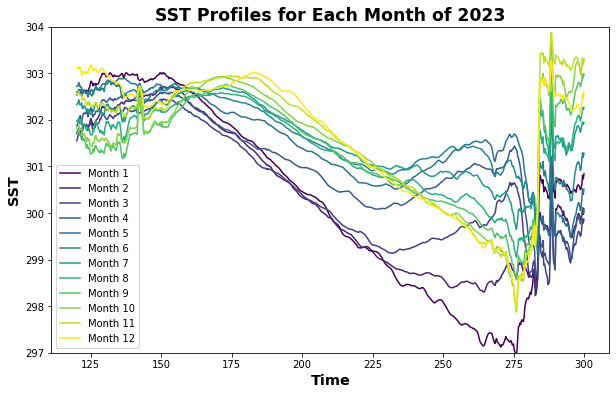

In [81]:
# Assuming `sst_profile` is your xarray DataArray or Dataset with 'time' and 'sst' variables

# Define the months
months = range(1, 13)

# Create a colormap with 12 distinct colors
cmap = plt.get_cmap('viridis')  # 'tab12' has 12 distinct colors
colors = [cmap(i) for i in np.linspace(0, 1, len(months))]

plt.figure(figsize=(10, 6))

# Plot the SST profiles for each month with corresponding colors
for m, color in zip(months, colors):
    sst_profile.sel(time='2023-{:02d}'.format(m)).sst.plot(label='Month {}'.format(m), color=color)

    

plt.legend()
plt.title('SST Profiles for Each Month of 2023')
plt.xlabel('Time')
plt.ylabel('SST')
plt.ylim(297, 304)
plt.show()


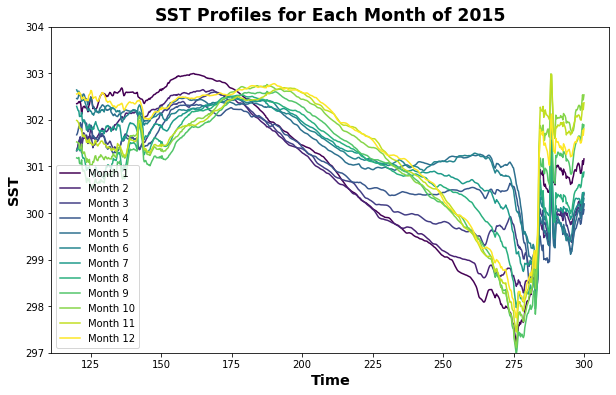

In [108]:
# Assuming `sst_profile` is your xarray DataArray or Dataset with 'time' and 'sst' variables

# Define the months
months = range(1, 13)

# Create a colormap with 12 distinct colors
cmap = plt.get_cmap('viridis')  # 'tab12' has 12 distinct colors
colors = [cmap(i) for i in np.linspace(0, 1, len(months))]

plt.figure(figsize=(10, 6))

# Plot the SST profiles for each month with corresponding colors
for m, color in zip(months, colors):
    sst_profile.sel(time='2015-{:02d}'.format(m)).sst.plot(label='Month {}'.format(m), color=color)
    

plt.legend()
plt.title('SST Profiles for Each Month of 2015')
plt.xlabel('Time')
plt.ylabel('SST')
plt.ylim(297, 304)

plt.show()


<Figure size 720x432 with 0 Axes>

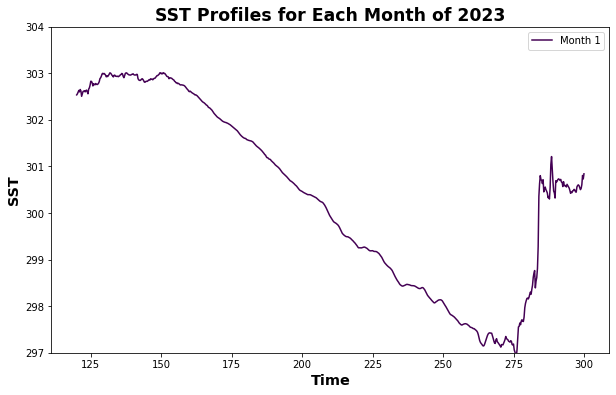

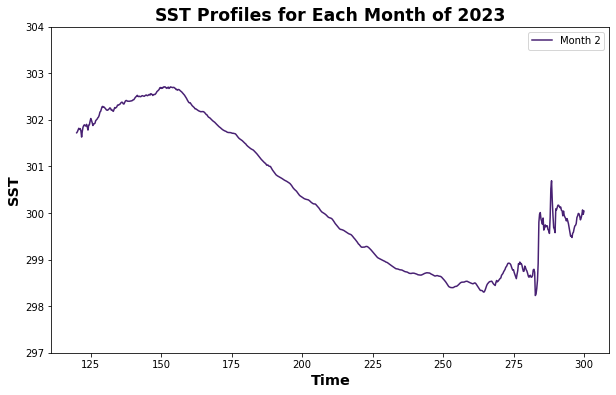

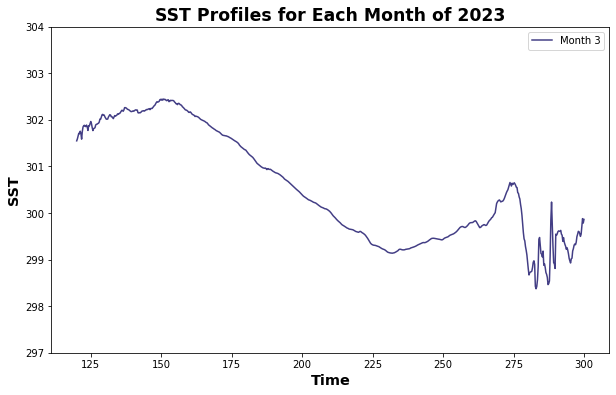

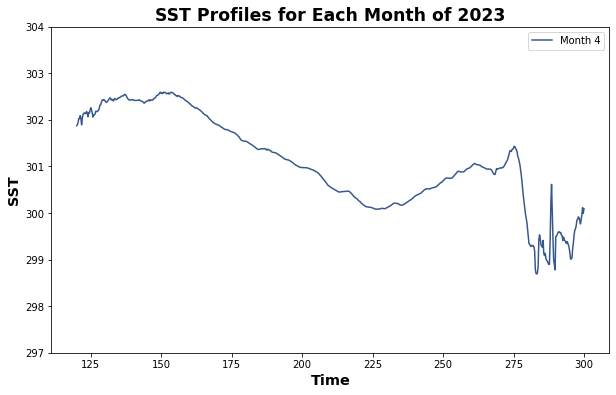

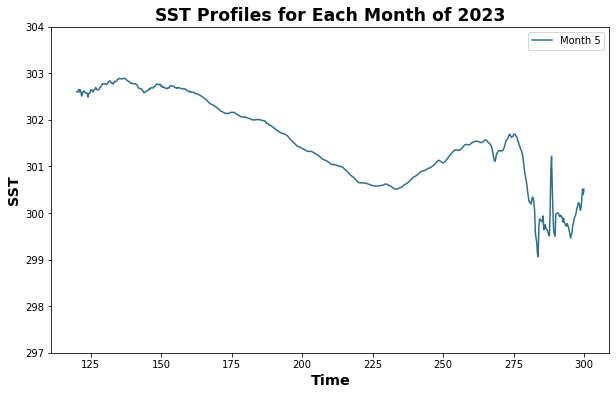

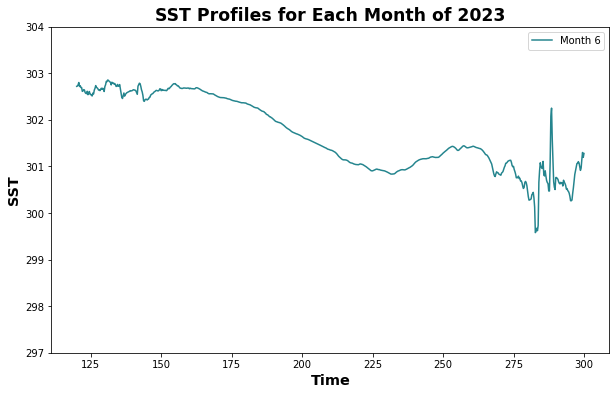

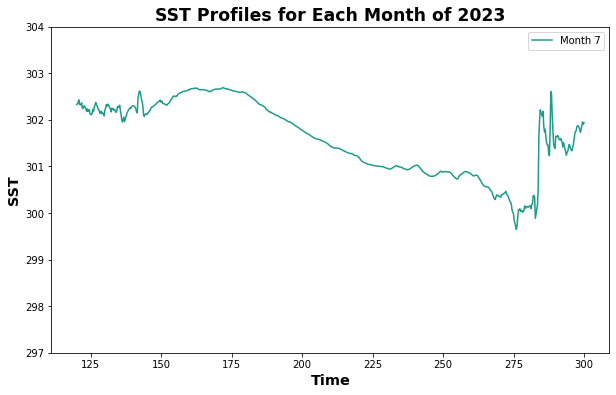

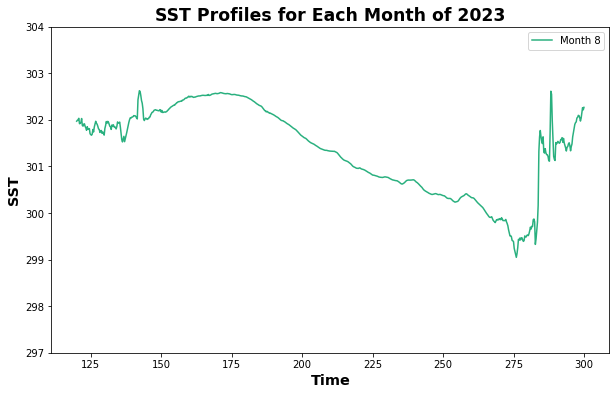

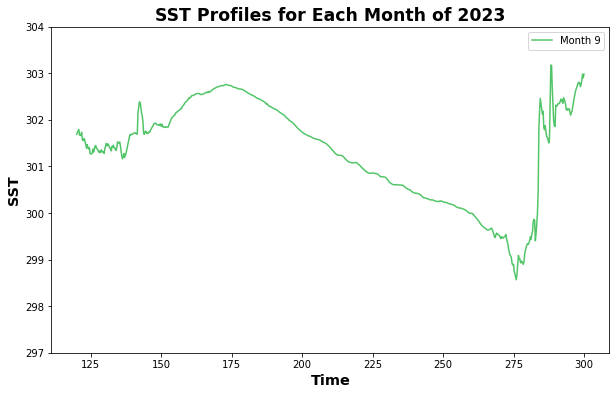

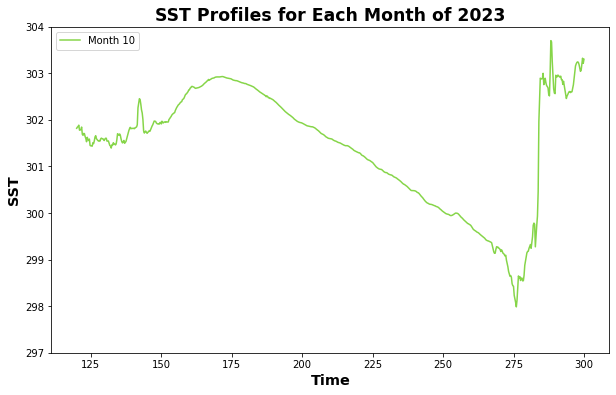

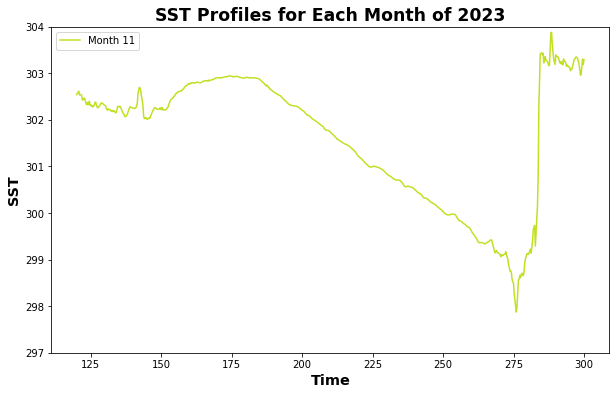

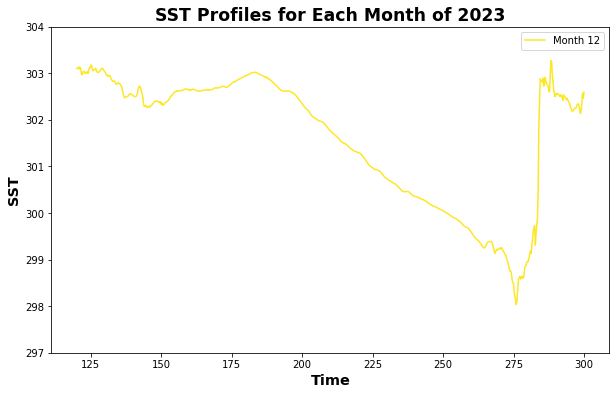

In [101]:
# Assuming `sst_profile` is your xarray DataArray or Dataset with 'time' and 'sst' variables

# Define the months
months = range(1, 13)

# Create a colormap with 12 distinct colors
cmap = plt.get_cmap('viridis')  # 'tab12' has 12 distinct colors
colors = [cmap(i) for i in np.linspace(0, 1, len(months))]

plt.figure(figsize=(10, 6))

# Plot the SST profiles for each month with corresponding colors
for m, color in zip(months, colors):
    plt.figure(figsize=(10, 6))

    sst_profile.sel(time='2023-{:02d}'.format(m)).sst.plot(label='Month {}'.format(m), color=color)

    plt.legend()
    plt.title('SST Profiles for Each Month of 2023')
    plt.xlabel('Time')
    plt.ylabel('SST')
    plt.ylim(297, 304)

    plt.show()

<Figure size 720x432 with 0 Axes>

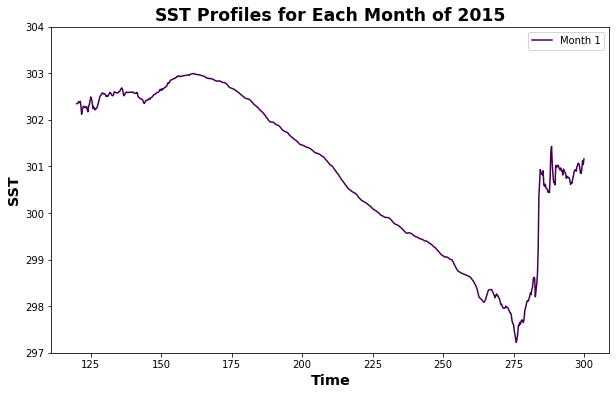

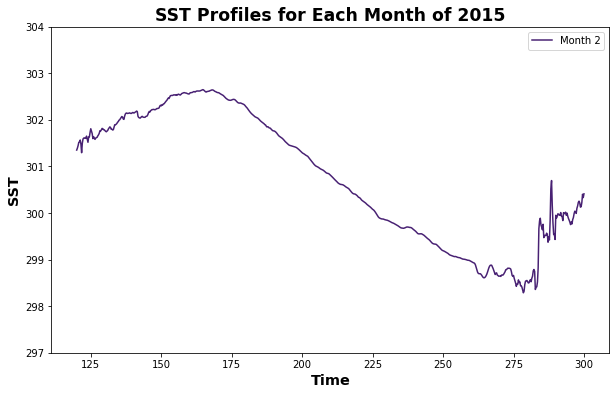

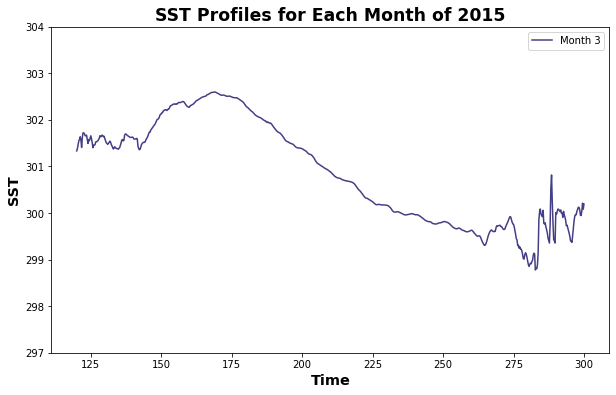

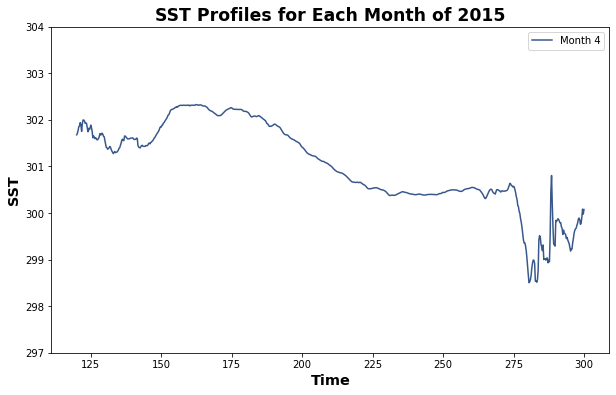

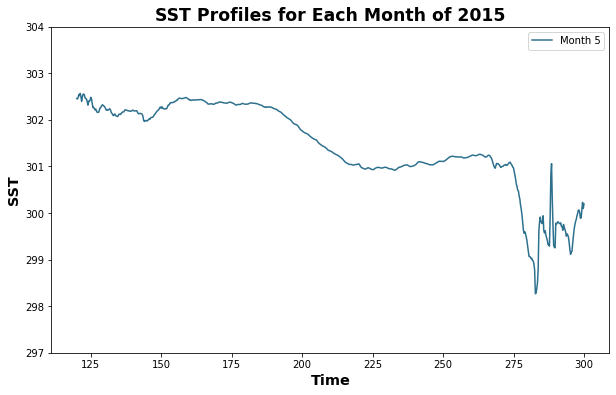

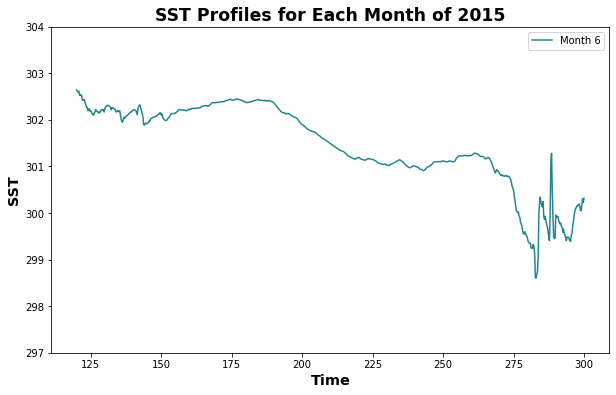

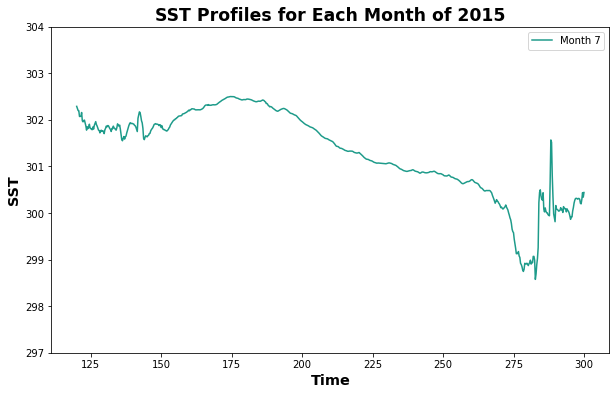

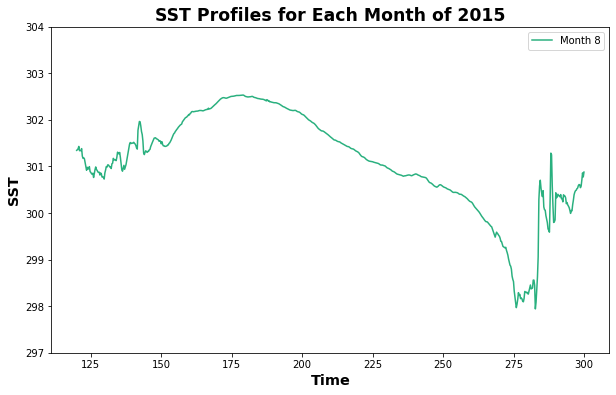

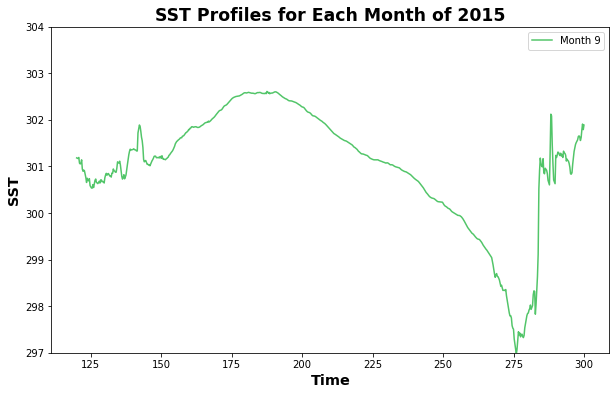

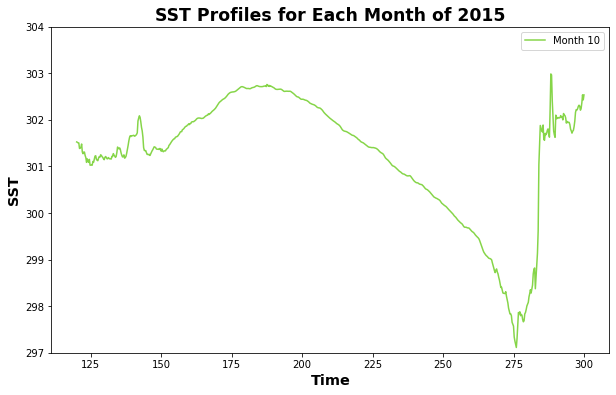

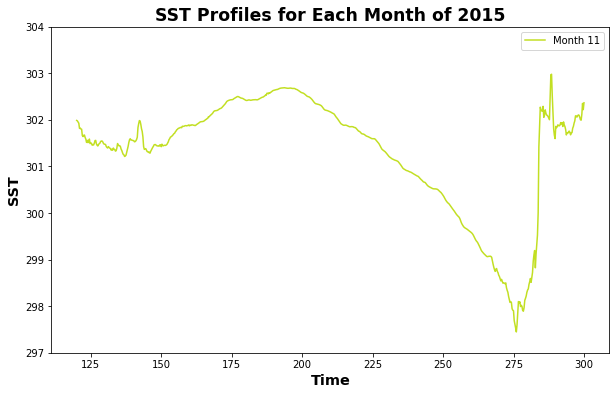

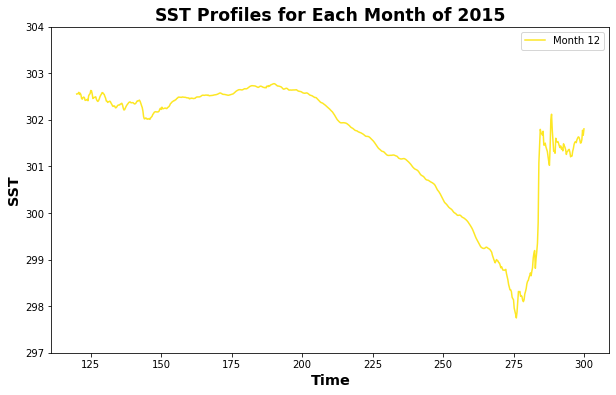

In [102]:
# Assuming `sst_profile` is your xarray DataArray or Dataset with 'time' and 'sst' variables

# Define the months
months = range(1, 13)

# Create a colormap with 12 distinct colors
cmap = plt.get_cmap('viridis')  # 'tab12' has 12 distinct colors
colors = [cmap(i) for i in np.linspace(0, 1, len(months))]

plt.figure(figsize=(10, 6))

# Plot the SST profiles for each month with corresponding colors
for m, color in zip(months, colors):
    plt.figure(figsize=(10, 6))

    sst_profile.sel(time='2015-{:02d}'.format(m)).sst.plot(label='Month {}'.format(m), color=color)

    plt.legend()
    plt.title('SST Profiles for Each Month of 2015')
    plt.xlabel('Time')
    plt.ylabel('SST')
    plt.ylim(297, 304)

    plt.show()

<Figure size 720x432 with 0 Axes>

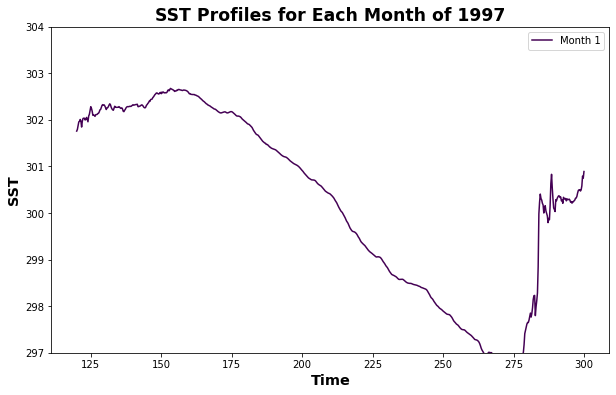

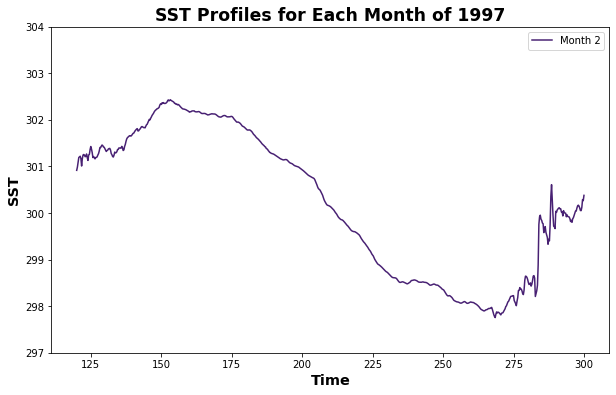

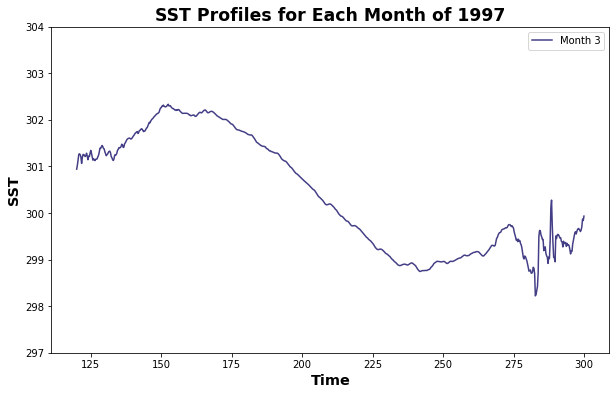

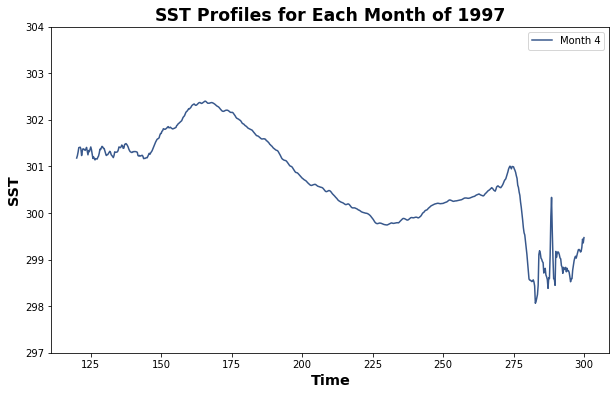

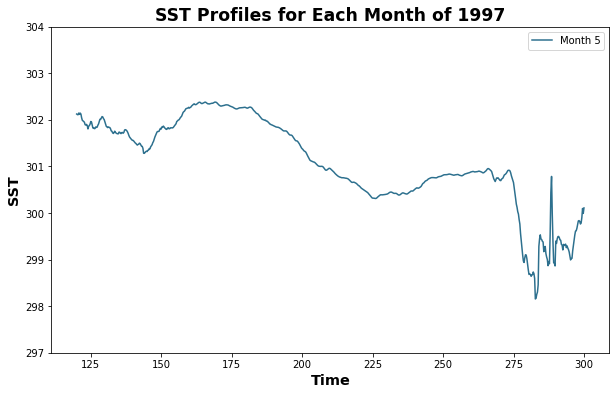

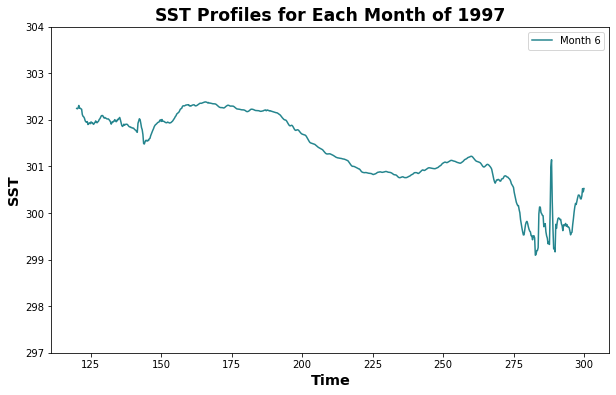

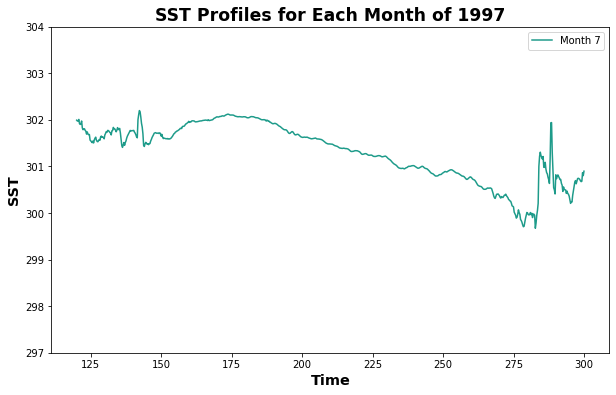

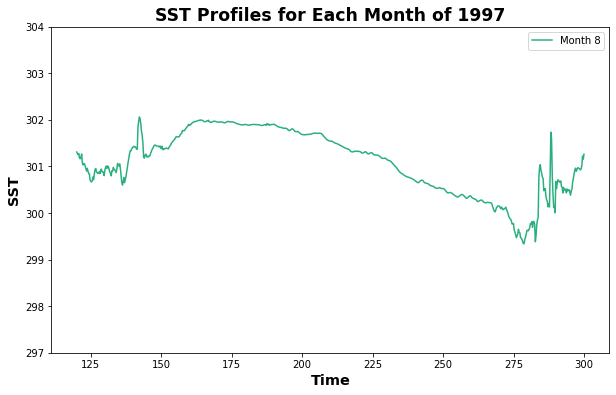

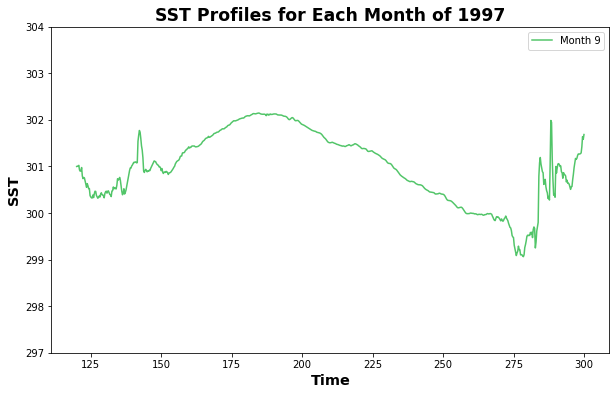

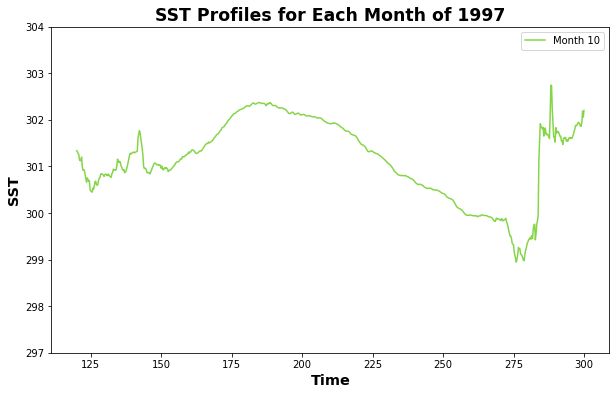

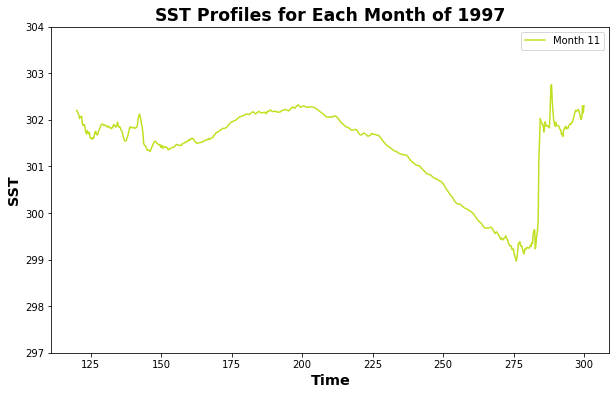

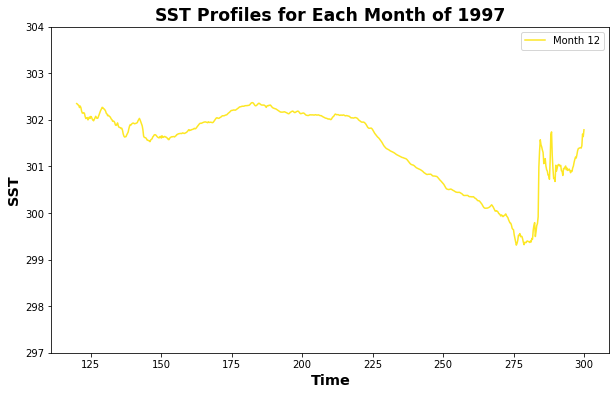

In [100]:
# Assuming `sst_profile` is your xarray DataArray or Dataset with 'time' and 'sst' variables

# Define the months
months = range(1, 13)

# Create a colormap with 12 distinct colors
cmap = plt.get_cmap('viridis')  # 'tab12' has 12 distinct colors
colors = [cmap(i) for i in np.linspace(0, 1, len(months))]

plt.figure(figsize=(10, 6))

# Plot the SST profiles for each month with corresponding colors
for m, color in zip(months, colors):
    plt.figure(figsize=(10, 6))

    sst_profile.sel(time='1997-{:02d}'.format(m)).sst.plot(label='Month {}'.format(m), color=color)

    plt.legend()
    plt.title('SST Profiles for Each Month of 1997')
    plt.xlabel('Time')
    plt.ylabel('SST')
    plt.ylim(297, 304)

    plt.show()

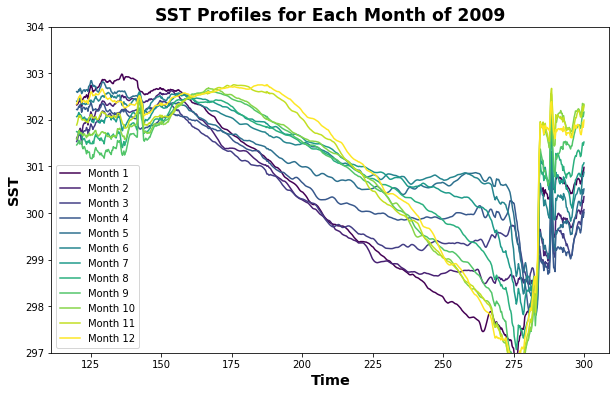

In [84]:
# Assuming `sst_profile` is your xarray DataArray or Dataset with 'time' and 'sst' variables

# Define the months
months = range(1, 13)

# Create a colormap with 12 distinct colors
cmap = plt.get_cmap('viridis')  # 'tab12' has 12 distinct colors
colors = [cmap(i) for i in np.linspace(0, 1, len(months))]

plt.figure(figsize=(10, 6))

# Plot the SST profiles for each month with corresponding colors
for m, color in zip(months, colors):
    sst_profile.sel(time='2009-{:02d}'.format(m)).sst.plot(label='Month {}'.format(m), color=color)

plt.legend()
plt.title('SST Profiles for Each Month of 2009')
plt.xlabel('Time')
plt.ylabel('SST')
plt.ylim(297, 304)

plt.show()

Updating for month: 2015-01
Time data: ['2015-01-01T00:00:00.000000000']...
SST data: [[302.34714 302.34964 302.36313 302.3903  302.37015 302.3983  302.30725
  302.11887 302.2228  302.27325 302.28674 302.2916  302.2572  302.26657
  302.28326 302.22064 302.17276 302.29724 302.32834 302.41187 302.49176
  302.4532  302.37378 302.24106 302.28595 302.25156 302.2127  302.2334
  302.24185 302.2704  302.32065 302.3746  302.43588 302.5036  302.5198
  302.5439  302.57666 302.57397 302.55402 302.56323 302.5528  302.53455
  302.49826 302.51965 302.50098 302.52625 302.5557  302.5882  302.57825
  302.5537  302.52542 302.51663 302.52774 302.5904  302.60245 302.58276
  302.58438 302.57806 302.57333 302.58844 302.6061  302.60876 302.6412
  302.66885 302.6858  302.653   302.57532 302.51654 302.53278 302.57294
  302.59155 302.59354 302.58536 302.59094 302.58823 302.5905  302.59164
  302.59186 302.5933  302.5972  302.59686 302.57635 302.57062 302.56702
  302.56918 302.583   302.58868 302.50037 302.48273 3

Updating for month: 2015-03
Time data: ['2015-03-01T00:00:00.000000000']...
SST data: [[301.33234 301.3823  301.4606  301.5492  301.57977 301.63638 301.56934
  301.40665 301.6199  301.7211  301.71918 301.7007  301.65924 301.65598
  301.67154 301.58057 301.49216 301.57568 301.55096 301.60822 301.65683
  301.5946  301.51364 301.4008  301.458   301.45645 301.46848 301.52234
  301.53162 301.53256 301.55014 301.57544 301.60037 301.6593  301.63898
  301.64188 301.6713  301.6604  301.63803 301.64664 301.59357 301.55115
  301.50443 301.49625 301.47235 301.49277 301.5147  301.54303 301.5247
  301.4753  301.44214 301.4067  301.374   301.39417 301.42252 301.39676
  301.3932  301.38147 301.38095 301.36792 301.3902  301.40256 301.45084
  301.50363 301.56387 301.57715 301.54654 301.56158 301.66965 301.69626
  301.6935  301.6804  301.66147 301.65463 301.64185 301.63318 301.62268
  301.62314 301.62454 301.63007 301.6216  301.5917  301.58603 301.58783
  301.59256 301.60126 301.5887  301.43112 301.3813 

Time data: ['2015-05-01T00:00:00.000000000']...
SST data: [[302.45712 302.4473  302.4754  302.54117 302.51978 302.56757 302.50052
  302.397   302.488   302.54794 302.5547  302.5279  302.46494 302.45862
  302.44287 302.38803 302.31488 302.40216 302.39325 302.42633 302.4831
  302.45004 302.36273 302.26245 302.26843 302.24506 302.21146 302.23087
  302.19394 302.16156 302.16046 302.16122 302.1969  302.25415 302.26022
  302.2908  302.31512 302.32193 302.30023 302.29266 302.27133 302.2429
  302.2079  302.21484 302.20395 302.21503 302.22437 302.23752 302.21118
  302.15933 302.1391  302.11435 302.09018 302.10645 302.12665 302.09857
  302.08374 302.07483 302.07028 302.08926 302.12173 302.1209  302.11526
  302.13202 302.14758 302.1667  302.16895 302.17126 302.20813 302.21353
  302.21063 302.20706 302.19662 302.19717 302.19095 302.18823 302.183
  302.18564 302.19012 302.20184 302.20834 302.1928  302.1911  302.19156
  302.19302 302.196   302.17438 302.13986 302.12802 302.1346  302.13763
  302.1364

Updating for month: 2015-07
Time data: ['2015-07-01T00:00:00.000000000']...
SST data: [[302.28897 302.24527 302.20007 302.1948  302.07202 302.07233 302.075
  302.15738 301.9796  301.95612 301.9871  301.99368 301.93533 301.87006
  301.77853 301.85098 301.81293 301.84314 301.90552 301.82135 301.8132
  301.7971  301.78772 301.84674 301.79977 301.8809  301.9184  301.96118
  301.8982  301.86676 301.82126 301.779   301.76996 301.7203  301.76874
  301.77643 301.74896 301.76675 301.74957 301.70377 301.78568 301.8172
  301.86594 301.8496  301.87604 301.87448 301.8419  301.81192 301.793
  301.75012 301.81622 301.8092  301.86444 301.82693 301.8176  301.7934
  301.77856 301.83    301.91406 301.8856  301.86404 301.88678 301.79614
  301.67743 301.57278 301.5512  301.6022  301.64163 301.58652 301.63107
  301.65176 301.71667 301.77042 301.8236  301.87408 301.91342 301.93866
  301.91702 301.92462 301.9218  301.91272 301.90903 301.8844  301.8728
  301.84476 301.79614 301.74844 302.03296 302.10126 302.17

Updating for month: 2015-09
Time data: ['2015-09-01T00:00:00.000000000']...
SST data: [[301.18307 301.17355 301.1713  301.19235 301.07    301.05396 301.06406
  301.14114 300.94504 300.89606 300.921   300.90656 300.82736 300.76074
  300.65558 300.74612 300.7057  300.69135 300.73727 300.58795 300.5602
  300.5356  300.53418 300.6087  300.5471  300.6209  300.70154 300.72922
  300.65884 300.64563 300.63086 300.65558 300.68146 300.6427  300.71008
  300.7105  300.6703  300.6788  300.66943 300.64426 300.75897 300.8142
  300.85114 300.8117  300.83633 300.84784 300.8182  300.79337 300.79727
  300.77097 300.85678 300.85266 300.94464 300.9087  300.89975 300.8755
  300.87646 300.96344 301.09845 301.07956 301.0716  301.11215 301.03485
  300.90036 300.78595 300.72818 300.76196 300.82224 300.7344  300.7722
  300.817   300.9216  301.04028 301.15057 301.2518  301.32544 301.36975
  301.34976 301.3593  301.35913 301.36545 301.3783  301.35934 301.35742
  301.3482  301.33167 301.33163 301.71982 301.81073 30

Updating for month: 2015-11
Time data: ['2015-11-01T00:00:00.000000000']...
SST data: [[301.98697 301.97708 301.95074 301.9265  301.81503 301.82217 301.80353
  301.79816 301.6637  301.63995 301.66962 301.67355 301.61954 301.58435
  301.5154  301.55975 301.5104  301.52905 301.58688 301.48944 301.50308
  301.49646 301.45535 301.46747 301.46027 301.49887 301.55475 301.55884
  301.48376 301.45425 301.43884 301.46945 301.48874 301.5004  301.53635
  301.54425 301.54633 301.52686 301.49255 301.47824 301.47626 301.4699
  301.42706 301.40652 301.39532 301.42566 301.40576 301.39215 301.3813
  301.3492  301.36923 301.34793 301.394   301.36942 301.36145 301.32843
  301.33752 301.3923  301.49103 301.4669  301.4424  301.44443 301.42932
  301.37317 301.3427  301.29633 301.2602  301.24908 301.2135  301.22324
  301.24173 301.30203 301.36688 301.42978 301.5132  301.5721  301.59525
  301.56674 301.56638 301.5601  301.5565  301.55203 301.52875 301.53278
  301.54993 301.57825 301.62674 301.83533 301.91748 

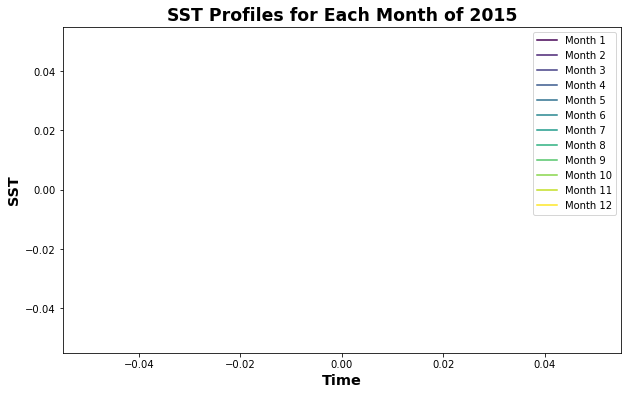

In [97]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

# Assuming `sst_profile` is your xarray DataArray or Dataset with 'time' and 'sst' variables

# Define the months
months = range(1, 13)

# Create a colormap with 12 distinct colors
cmap = plt.get_cmap('viridis')
colors = [cmap(i) for i in np.linspace(0, 1, len(months))]

# Set up the figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Initialize the lines for each month
lines = [ax.plot([], [], label=f'Month {m}', color=colors[m-1])[0] for m in months]

# Function to initialize the plot
def init():
    for line in lines:
        line.set_data([], [])
    return lines

# Function to update the plot for each frame
def update(frame):
    m = frame + 1
    time = '2015-{:02d}'.format(m)
    print(f"Updating for month: {time}")  # Debug print
    sst_data = sst_profile.sel(time=time).sst
    times = sst_data['time'].values
    values = sst_data.values
    print(f"Time data: {times[:5]}...")  # Debug print
    print(f"SST data: {values[:5]}...")  # Debug print
    lines[frame].set_data(times, values)
    ax.legend()
    return lines

# Create the animation
ani = animation.FuncAnimation(fig, update, frames=len(months), init_func=init, blit=False, repeat=False)

# Save the animation
ani.save('sst_profiles_animation.mp4', writer='ffmpeg', fps=1)

plt.title('SST Profiles for Each Month of 2015')
plt.xlabel('Time')
plt.ylabel('SST')
plt.show()



In [94]:
sst_profile.sel(time = '2015')

<xarray.Dataset>
Dimensions:  (time: 889, lon: 721)
Coordinates:
  * time     (time) datetime64[ns] 1950-02-01 1950-03-01 ... 2024-02-01
  * lon      (lon) float64 120.0 120.2 120.5 120.8 ... 299.2 299.5 299.8 300.0
Data variables:
    sst      (time, lon) float32 301.6 301.5 301.6 301.6 ... 301.3 301.3 301.4

In [43]:
# Function to compute the mean of the top 30% of the values
def top_30_percent_mean(data):
    threshold = data.quantile(0.70, dim=['lat', 'lon'])  # 70th percentile threshold
    top_30 = data.where(data >= threshold)
    return top_30.mean(dim=['lat', 'lon'])

In [44]:
# Calculate the mean SST for the top 30% for each time step
mean_top_30 = sst.sst.groupby('time').apply(top_30_percent_mean)

# Calculate the overall mean SST for each time step
mean_sst = sst.sst.mean(dim=['lat', 'lon'])

# Subtract the overall mean SST from the top 30% mean SST
sst_diff = mean_top_30 - mean_sst

# Assign the result to a new variable in the dataset
sst['sst#'] = sst_diff#.groupby('time.month') - sst_diff.groupby('time.month').mean()

# Save or print the resulting dataset


In [45]:

# Assign the result to a new variable in the dataset
sst['sst#'] = sst_diff.groupby('time.month') - sst_diff.groupby('time.month').mean()


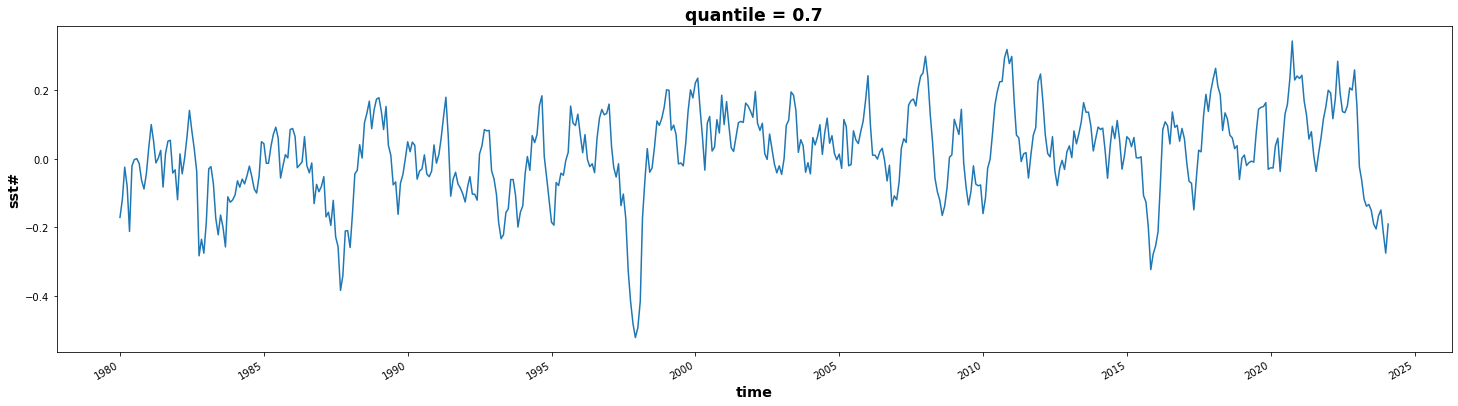

In [46]:
fig = plt.subplots(figsize = (25,6))
sst.sel(time = slice('1980', None))['sst#'].plot()

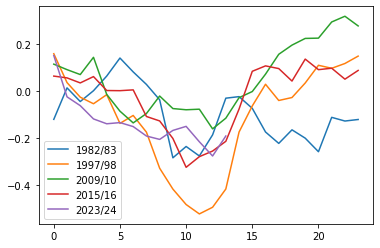

In [48]:
plt.plot(sst.sel(time = slice('1982', '1983'))['sst#'], label = '1982/83')

plt.plot(sst.sel(time = slice('1997', '1998'))['sst#'], label = '1997/98')

plt.plot(sst.sel(time = slice('2009', '2010'))['sst#'], label = '2009/10')


plt.plot(sst.sel(time = slice('2015', '2016'))['sst#'], label = '2015/16')

plt.plot(sst.sel(time = slice('2023', '2024'))['sst#'], label = '2023/24')

plt.legend()